In [139]:
import numpy as np
from matplotlib import pyplot as plt
import scipy
import os
import torch
import seaborn as sns
from numpy.linalg import norm

In [140]:
np.random.seed(10212)

dim_input = 100
dim_class = 50


def label_smoothing(y, r=0.9):
    return np.ones_like(y) * (1 - r) / y.shape[0] + y * r


def get_W_K(y_k: list[int], X: np.ndarray, lr=10):
    W_t = np.random.randn(dim_class, dim_input)
    y = np.zeros((dim_class, 1))
    for i in range(len(y_k)):
        y[y_k[i]] = 1
    probs_t = scipy.special.softmax(W_t.dot(X), axis=0)
    W_t1 = W_t - lr * np.outer((probs_t - y), X)
    return W_t1


def zo_step(W_t, X, seeds: list[int], mu=1e-4, plus=21, plus_lr=0):
    y = np.zeros((dim_class, 1))
    y[plus] = 1
    y = label_smoothing(y, 1)

    def loss(W, y):
        logits = W.dot(X)
        # num_class * batch
        probs_t = scipy.special.softmax(W.dot(X), axis=0)
        return -np.log(y.T @ probs_t)[0]  # single float

    zo_grad = 0
    for seed in seeds:
        np.random.seed(seed)
        pert = np.random.randn(*W_t.shape)
        W_plus = W_t + mu * pert
        l_plus = loss(W_plus, y)
        W_minus = W_t - mu * pert
        l_minus = loss(W_minus, y)

        zo_dir = (l_plus - l_minus) / 2 / mu
        zo_grad += zo_dir * pert

    W_t1 = W_t - plus_lr * zo_grad / len(seeds)
    probs_t = scipy.special.softmax(W_t.dot(X), axis=0)
    probs_t1 = scipy.special.softmax(W_t1.dot(X), axis=0)
    return probs_t.squeeze(), probs_t1.squeeze()


def fo_step(W_t, X, plus=42, plus_lr=0, minus=21, minus_lr=0):
    logits = W_t.dot(X)
    y = np.zeros((dim_class, 1))
    y[minus] = 1
    y = label_smoothing(y, 1)

    y2 = np.zeros((dim_class, 1))
    y2[plus] = 1
    y2 = label_smoothing(y2, 1)

    probs_t = scipy.special.softmax(W_t.dot(X), axis=0)
    W_t1 = (
        W_t
        + minus_lr * np.outer((probs_t * 1 - y), X)
        - plus_lr * np.outer((probs_t - y2), X)
    )
    probs_t1 = scipy.special.softmax(W_t1.dot(X), axis=0)
    return probs_t.squeeze(), probs_t1.squeeze()

In [141]:
X = np.random.randn(dim_input, 1)
Wt_uniform = np.random.randn(dim_class, dim_input)
Wt_peaky = get_W_K(list(range(15, 22)), X, lr=1)

In [142]:
fo_probs_t, fo_probs_t1 = fo_step(W_t=Wt_uniform, X=X, plus=9, plus_lr=0.5)
zo_probs_t, zo_probs_t1 = zo_step(
    W_t=Wt_uniform, X=X, seeds=range(20, 30), plus=9, plus_lr=0.5
)

In [143]:
def plot(prob, prob_next, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    x_axis = np.arange(0, len(prob))
    ax.step(x_axis, prob)
    ax.step(x_axis, prob_next)
    ax.set_yscale("log")
    return ax

<Axes: >

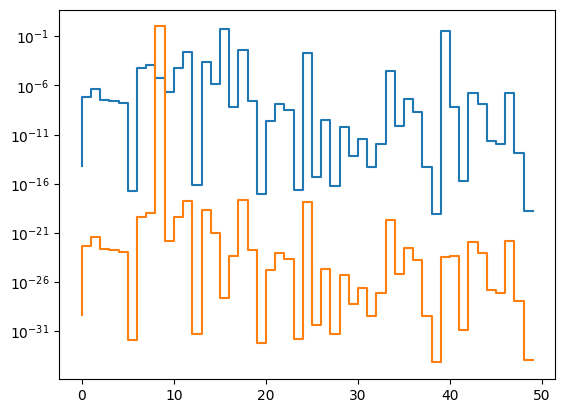

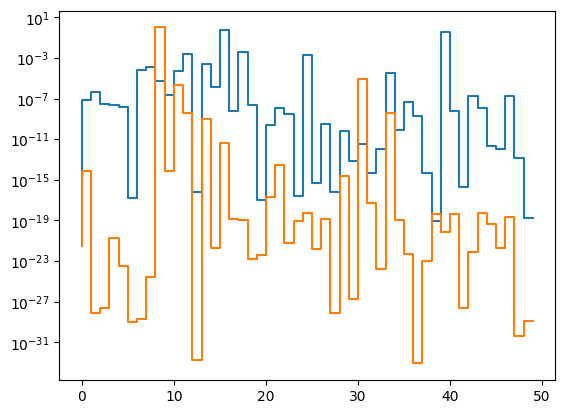

In [144]:
plot(fo_probs_t, fo_probs_t1)
plot(zo_probs_t, zo_probs_t1)

## Computing Frobenius norm difference of FO and ZO

In [145]:
def compute_frobenius(K_fo, K_zo):
    return norm(K_fo - K_zo, "fro")

# The impact of the number of perturbations

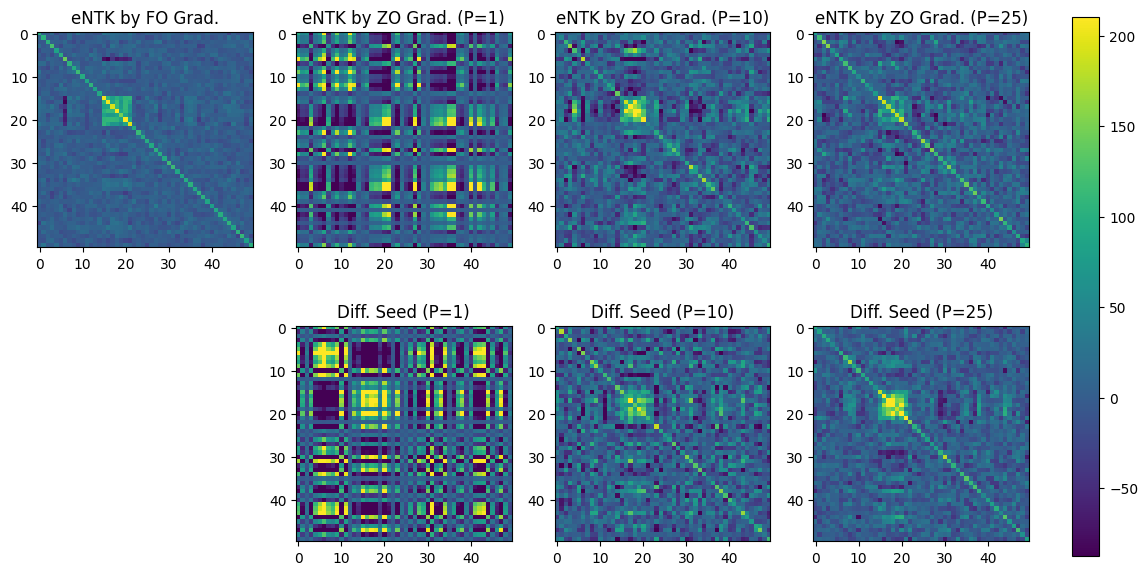

In [160]:
vmin = K_fo.min()
vmax = K_fo.max()
cmap_choice = "viridis"

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
K_fo = Wt_peaky @ Wt_peaky.T
axes[0, 0].imshow(K_fo, cmap=cmap_choice, vmin=vmin, vmax=vmax)
axes[0, 0].set_title("eNTK by FO Grad.")
axes[1, 0].axis("off")

for i, perturb in enumerate([1, 10, 25]):
    np.random.seed(10086 + i)
    u = np.random.randn(dim_input, perturb)
    K_zo = Wt_peaky @ (u @ u.T / perturb) @ Wt_peaky.T
    im = axes[0, i + 1].imshow(K_zo, vmin=vmin, vmax=vmax, cmap=cmap_choice)
    axes[0, i + 1].set_title(f"eNTK by ZO Grad. (P={perturb})")

    np.random.seed(10086 + (i + 1) * 2)
    u = np.random.randn(dim_input, perturb)
    K_zo = Wt_peaky @ (u @ u.T / perturb) @ Wt_peaky.T
    im = axes[1, i + 1].imshow(K_zo, vmin=vmin, vmax=vmax, cmap=cmap_choice)
    axes[1, i + 1].set_title(f"Diff. Seed (P={perturb})")

fig.colorbar(im, ax=axes, fraction=0.046, pad=0.04)

plt.savefig("figures/eNTK_pert.pdf", format="pdf")

# The impact of perturbation distribution

0
1
2


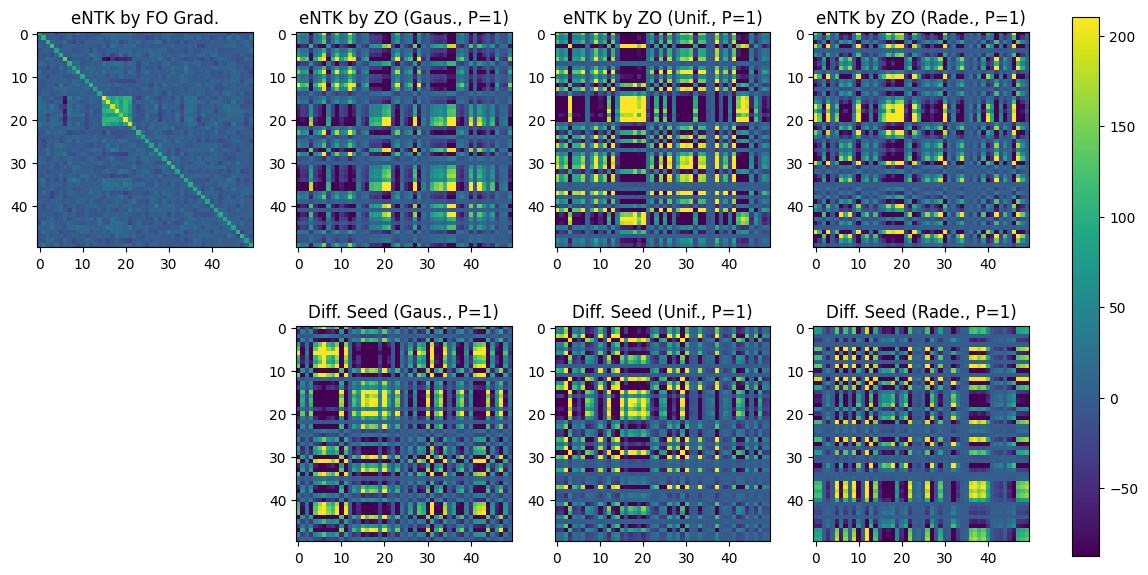

In [164]:
PERT = 1
vmin = K_fo.min()
vmax = K_fo.max()
cmap_choice = "viridis"

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
K_fo = Wt_peaky @ Wt_peaky.T
axes[0, 0].imshow(K_fo, cmap=cmap_choice, vmin=vmin, vmax=vmax)
axes[0, 0].set_title("eNTK by FO Grad.")
axes[1, 0].axis("off")

for i, dist in enumerate(["Gaus.", "Unif.", "Rade."]):
    print(i)
    np.random.seed(10086 + i)
    if dist == "Gaus.":
        u = np.random.randn(dim_input, PERT)
    elif dist == "Unif.":
        u = np.random.uniform(-1, 1, size=(dim_input, PERT)) * np.sqrt(3)
    elif dist == "Rade.":
        u = np.random.choice([-1, 1], size=(dim_input, PERT))
    K_zo = Wt_peaky @ (u @ u.T / PERT) @ Wt_peaky.T
    im = axes[0, i + 1].imshow(K_zo, vmin=vmin, vmax=vmax, cmap=cmap_choice)
    axes[0, i + 1].set_title(f"eNTK by ZO ({dist}, P={PERT})")
    # frobenius_norm = compute_frobenius(K_fo=K_fo, K_zo=K_zo)
    # print(f"{dist}: frob_norm={frobenius_norm:.2f}")

    np.random.seed(10086 + (i + 1) * 2)
    if dist == "Gaus.":
        u = np.random.randn(dim_input, PERT)
    elif dist == "Unif.":
        u = np.random.uniform(-1, 1, size=(dim_input, PERT)) * np.sqrt(3)
    elif dist == "Rade.":
        u = np.random.choice([-1, 1], size=(dim_input, PERT))
    K_zo = Wt_peaky @ (u @ u.T / PERT) @ Wt_peaky.T
    im = axes[1, i + 1].imshow(K_zo, vmin=vmin, vmax=vmax, cmap=cmap_choice)
    axes[1, i + 1].set_title(f"Diff. Seed ({dist}, P={PERT})")
    # frobenius_norm = compute_frobenius(K_fo=K_fo, K_zo=K_zo)
    # print(f"{dist}: frob_norm={frobenius_norm:.2f}")

fig.colorbar(im, ax=axes, fraction=0.046, pad=0.04)

plt.savefig(f"figures/eNTK_dist_P{PERT}.pdf", format="pdf")

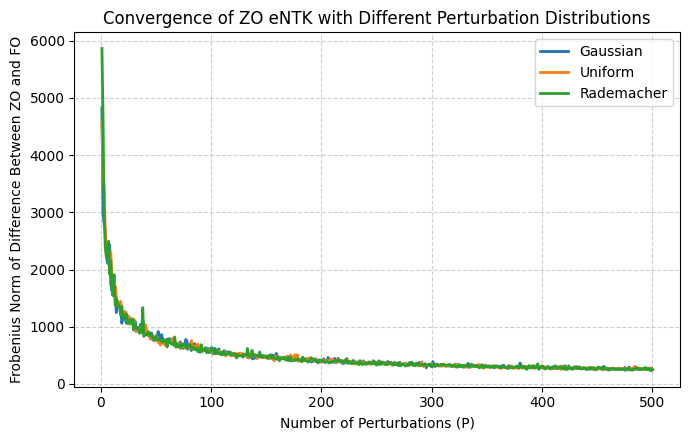

In [169]:
PERT_range = np.arange(1, 501)
frob_values = []
K_fo = Wt_peaky @ Wt_peaky.T

frob_gaus, frob_unif, frob_rade = [], [], []

for PERT in PERT_range:
    np.random.seed(42)
    # Gaussian
    u = np.random.randn(dim_input, PERT)
    K_zo = Wt_peaky @ (u @ u.T / PERT) @ Wt_peaky.T
    frob_gaus.append(compute_frobenius(K_fo, K_zo))

    # Uniform
    u = np.random.uniform(-1, 1, size=(dim_input, PERT)) * np.sqrt(3)
    K_zo = Wt_peaky @ (u @ u.T / PERT) @ Wt_peaky.T
    frob_unif.append(compute_frobenius(K_fo, K_zo))

    # Rademacher
    u = np.random.choice([-1, 1], size=(dim_input, PERT))
    K_zo = Wt_peaky @ (u @ u.T / PERT) @ Wt_peaky.T
    frob_rade.append(compute_frobenius(K_fo, K_zo))

plt.figure(figsize=(7, 4.5))
plt.plot(PERT_range, frob_gaus, label="Gaussian", color="tab:blue", linewidth=2)
plt.plot(PERT_range, frob_unif, label="Uniform", color="tab:orange", linewidth=2)
plt.plot(PERT_range, frob_rade, label="Rademacher", color="tab:green", linewidth=2)
plt.xlabel("Number of Perturbations (P)")
plt.ylabel("Frobenius Norm of Difference Between ZO and FO")
plt.title("Convergence of ZO eNTK with Different Perturbation Distributions")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig(f"figures/zo_eNTK_different_dist.pdf", format="pdf")
plt.show()